# Financial Market Risk & Return Analysis  
### A Python / Google Colab Portfolio Project

**Project theme:** Analyse real stock market data using Python to compare performance, volatility, drawdowns, correlations and risk-adjusted returns.

This notebook downloads live historical market data using `yfinance`, cleans and reshapes the dataset, calculates financial indicators, and produces visualisations suitable for a GitHub portfolio.

## Assets analysed
The project compares a small portfolio of major technology and market benchmark assets:

- NVIDIA (`NVDA`)
- Tesla (`TSLA`)
- Apple (`AAPL`)
- Microsoft (`MSFT`)
- S&P 500 ETF (`SPY`)

## Skills demonstrated

- Real-world data collection using Python
- Data cleaning and preprocessing
- Exploratory data analysis
- Financial return calculation
- Volatility and risk analysis
- Correlation analysis
- Drawdown analysis
- Sharpe ratio comparison
- Data visualisation with Matplotlib and Seaborn


## 1. Install and import libraries

This notebook is designed to run directly in Google Colab.  
The data is downloaded from Yahoo Finance using the `yfinance` Python package.


In [1]:
# Install required package
!pip -q install yfinance

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

# Plot style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Download real financial data

The data is pulled directly using a Python command from Yahoo Finance through `yfinance`.

The date range can be adjusted, but this project focuses on the period from **2021 onwards**, which captures major market events such as the post-pandemic tech boom, interest rate pressures, the AI rally, and large changes in Tesla and NVIDIA valuations.


In [2]:
# Define assets and date range
tickers = ["NVDA", "TSLA", "AAPL", "MSFT", "SPY"]
start_date = "2021-01-01"
end_date = None  # None means download up to the latest available date

# Download adjusted close prices
raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)

# Use Close prices
prices = raw_data["Close"].copy()

# Preview
prices.head()

Ticker,AAPL,MSFT,NVDA,SPY,TSLA
Date,,,,,
2021-01-04,125.8567,208.4065,13.0760,343.3192,243.2567
2021-01-05,127.4127,208.6075,13.3664,345.6837,245.0367
2021-01-06,123.1238,203.1985,12.5784,347.7504,251.9933
2021-01-07,127.3252,208.9810,13.3059,352.9170,272.0133
2021-01-08,128.4242,210.2542,13.2388,354.9279,293.3400


## 3. Data cleaning and validation

Real financial datasets can contain missing values due to holidays, trading suspensions, or ticker-specific data issues.

This section checks:

- dataset shape
- missing values
- duplicate rows
- date index quality
- descriptive statistics


In [3]:
# Basic inspection
print("Dataset shape:", prices.shape)
print("\nDate range:", prices.index.min(), "to", prices.index.max())
print("\nMissing values by asset:")
print(prices.isna().sum())

print("\nDuplicate dates:", prices.index.duplicated().sum())

# Clean data
prices_clean = prices.dropna().copy()

print("\nCleaned dataset shape:", prices_clean.shape)
prices_clean.head()

Dataset shape: (1337, 5)

Date range: 2021-01-04 00:00:00 to 2026-04-30 00:00:00

Missing values by asset:
Ticker
AAPL    0
MSFT    0
NVDA    0
SPY     0
TSLA    0
dtype: int64

Duplicate dates: 0

Cleaned dataset shape: (1337, 5)


Ticker,AAPL,MSFT,NVDA,SPY,TSLA
Date,,,,,
2021-01-04,125.8567,208.4065,13.0760,343.3192,243.2567
2021-01-05,127.4127,208.6075,13.3664,345.6837,245.0367
2021-01-06,123.1238,203.1985,12.5784,347.7504,251.9933
2021-01-07,127.3252,208.9810,13.3059,352.9170,272.0133
2021-01-08,128.4242,210.2542,13.2388,354.9279,293.3400


In [4]:
# Descriptive statistics of prices
prices_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,"1,337.0000",184.3990,43.5538,113.3341,147.2308,174.5246,220.5611,285.9225
MSFT,"1,337.0000",346.3512,88.4970,203.1985,268.0151,327.6498,414.6043,539.8253
NVDA,"1,337.0000",74.5057,62.6547,11.2123,19.8595,44.2344,129.7975,216.6100
SPY,"1,337.0000",481.7111,105.4136,340.2528,394.2435,435.8216,569.0424,718.6600
TSLA,"1,337.0000",273.9075,81.8719,108.1000,214.8833,253.2100,331.3267,489.8800


## 4. Normalised price performance

Because each stock starts at a different price, comparing raw prices is misleading.  
To compare performance fairly, all assets are normalised to start at **100**.

This shows how much each asset would have grown relative to its starting value.


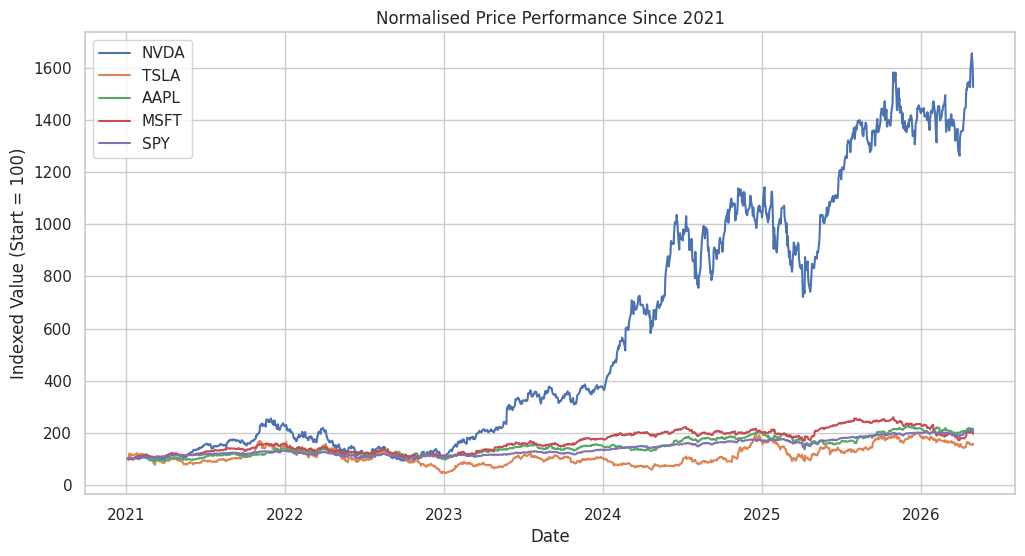

In [5]:
# Normalise prices to 100 at the start
normalised_prices = prices_clean / prices_clean.iloc[0] * 100

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(normalised_prices.index, normalised_prices[ticker], label=ticker)

plt.title("Normalised Price Performance Since 2021")
plt.xlabel("Date")
plt.ylabel("Indexed Value (Start = 100)")
plt.legend()
plt.show()

## 5. Daily returns

Financial analysis usually focuses on returns rather than prices.

Daily returns are calculated as:

\[
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
\]

where \(P_t\) is the adjusted closing price at time \(t\).


In [6]:
# Calculate daily returns
daily_returns = prices_clean.pct_change().dropna()

daily_returns.head()

Ticker,AAPL,MSFT,NVDA,SPY,TSLA
Date,,,,,
2021-01-05,0.0124,0.0010,0.0222,0.0069,0.0073
2021-01-06,-0.0337,-0.0259,-0.0590,0.0060,0.0284
2021-01-07,0.0341,0.0285,0.0578,0.0149,0.0794
2021-01-08,0.0086,0.0061,-0.0050,0.0057,0.0784
2021-01-11,-0.0232,-0.0097,0.0260,-0.0067,-0.0782


In [7]:
# Summary statistics for returns
return_summary = pd.DataFrame({
    "Mean Daily Return": daily_returns.mean(),
    "Daily Volatility": daily_returns.std(),
    "Annualised Return": daily_returns.mean() * 252,
    "Annualised Volatility": daily_returns.std() * np.sqrt(252)
})

return_summary.sort_values("Annualised Return", ascending=False)

,Mean Daily Return,Daily Volatility,Annualised Return,Annualised Volatility
Ticker,,,,
NVDA,0.0026,0.0324,0.6452,0.5139
TSLA,0.0010,0.0375,0.2613,0.5960
AAPL,0.0007,0.0174,0.1830,0.2767
MSFT,0.0006,0.0165,0.1611,0.2626
SPY,0.0006,0.0107,0.1537,0.1694


## 6. Distribution of daily returns

This visualisation shows how returns are distributed for each asset.

A wider distribution usually indicates higher volatility and greater risk.


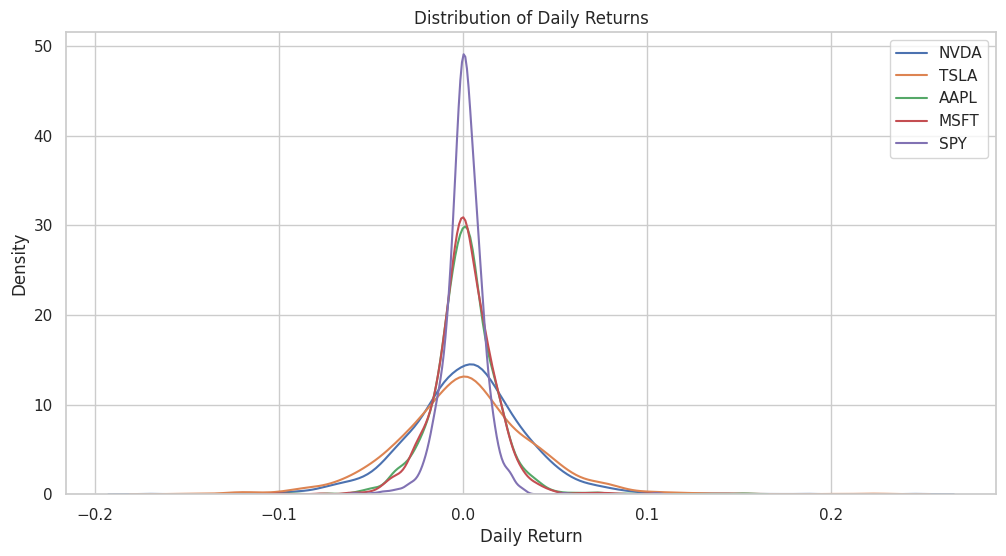

In [8]:
plt.figure(figsize=(12, 6))
for ticker in tickers:
    sns.kdeplot(daily_returns[ticker], label=ticker, fill=False)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")
plt.legend()
plt.show()

## 7. Correlation analysis

Correlation shows how closely assets move together.

This matters because a portfolio containing highly correlated assets may be less diversified than it appears.


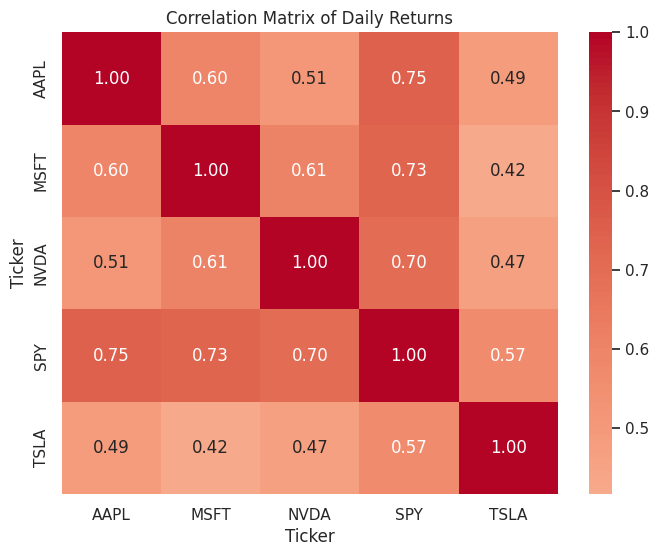

In [9]:
corr_matrix = daily_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix of Daily Returns")
plt.show()

## 8. Rolling volatility

Rolling volatility helps show how market risk changes over time.

This project uses a **30-day rolling annualised volatility** measure.


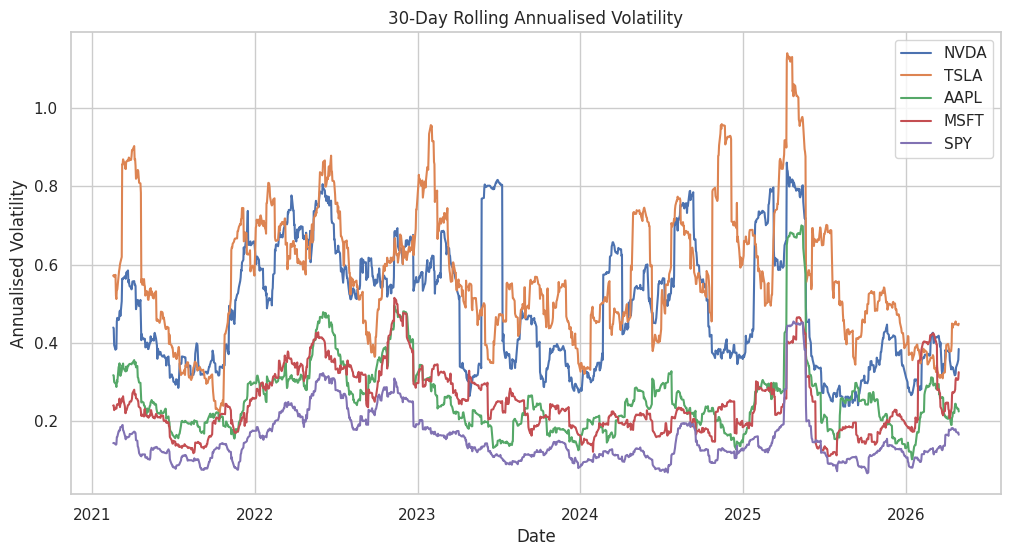

In [10]:
rolling_volatility = daily_returns.rolling(window=30).std() * np.sqrt(252)

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(rolling_volatility.index, rolling_volatility[ticker], label=ticker)

plt.title("30-Day Rolling Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.show()

## 9. Drawdown analysis

Drawdown measures the percentage fall from a previous peak.

It helps answer:

> If I invested at the worst possible time, how far would I have fallen before recovering?


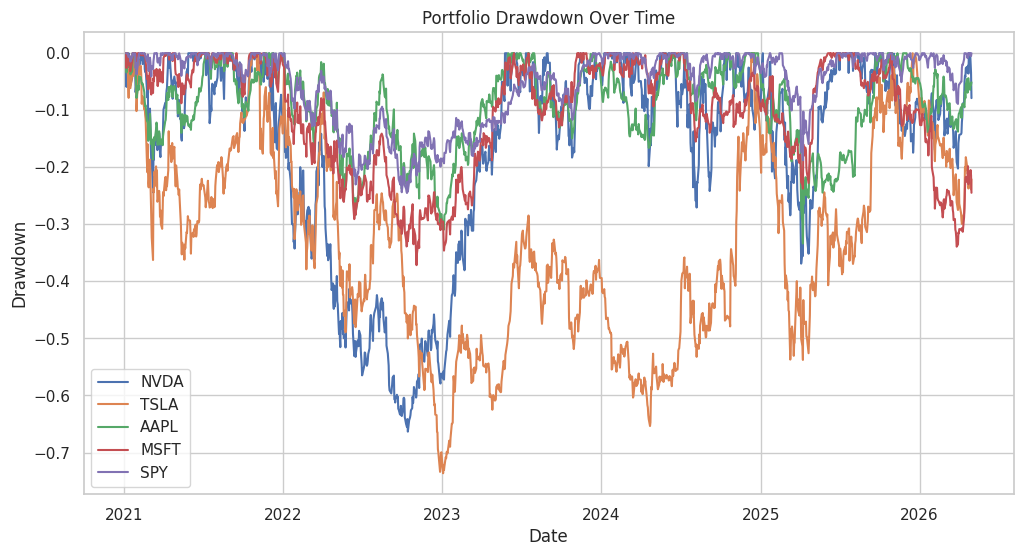

In [11]:
# Calculate cumulative returns
cumulative_returns = (1 + daily_returns).cumprod()

# Calculate running maximum
running_max = cumulative_returns.cummax()

# Calculate drawdowns
drawdowns = cumulative_returns / running_max - 1

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(drawdowns.index, drawdowns[ticker], label=ticker)

plt.title("Portfolio Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

In [12]:
max_drawdown = drawdowns.min().sort_values()

max_drawdown_df = pd.DataFrame({
    "Maximum Drawdown": max_drawdown
})

max_drawdown_df

,Maximum Drawdown
Ticker,
TSLA,-0.7363
NVDA,-0.6634
MSFT,-0.3715
AAPL,-0.3336
SPY,-0.2450


## 10. Sharpe ratio comparison

The Sharpe ratio measures risk-adjusted return.

A higher Sharpe ratio generally means better return per unit of risk.

For simplicity, this project assumes a risk-free rate of 0%. This can be adjusted if needed.


In [13]:
risk_free_rate = 0.00

annualised_return = daily_returns.mean() * 252
annualised_volatility = daily_returns.std() * np.sqrt(252)

sharpe_ratio = (annualised_return - risk_free_rate) / annualised_volatility

risk_return_table = pd.DataFrame({
    "Annualised Return": annualised_return,
    "Annualised Volatility": annualised_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Maximum Drawdown": max_drawdown
}).sort_values("Sharpe Ratio", ascending=False)

risk_return_table

,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown
Ticker,,,,
NVDA,0.6452,0.5139,1.2556,-0.6634
SPY,0.1537,0.1694,0.9073,-0.2450
AAPL,0.1830,0.2767,0.6615,-0.3336
MSFT,0.1611,0.2626,0.6135,-0.3715
TSLA,0.2613,0.5960,0.4384,-0.7363


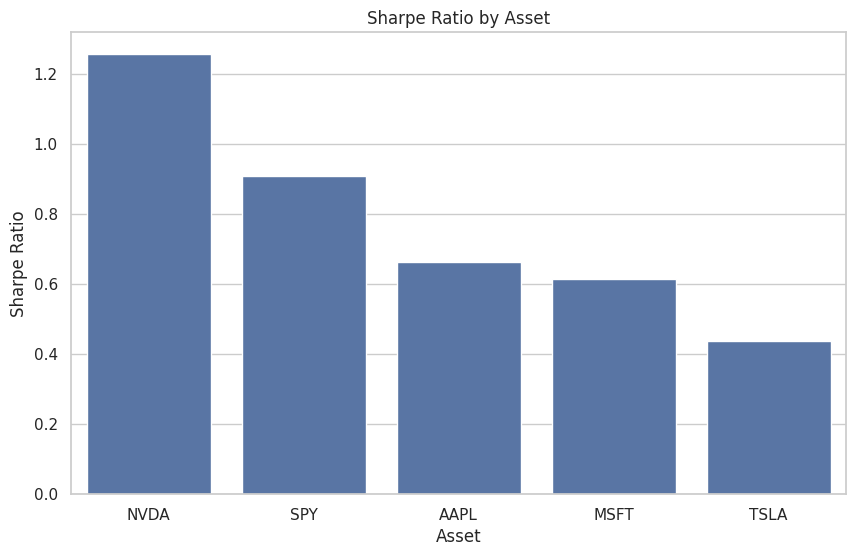

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=risk_return_table.index,
    y=risk_return_table["Sharpe Ratio"]
)

plt.title("Sharpe Ratio by Asset")
plt.xlabel("Asset")
plt.ylabel("Sharpe Ratio")
plt.show()

## 11. Risk-return scatter plot

This plot compares annualised return against annualised volatility.

Assets toward the upper-left generally offer stronger returns for lower risk.


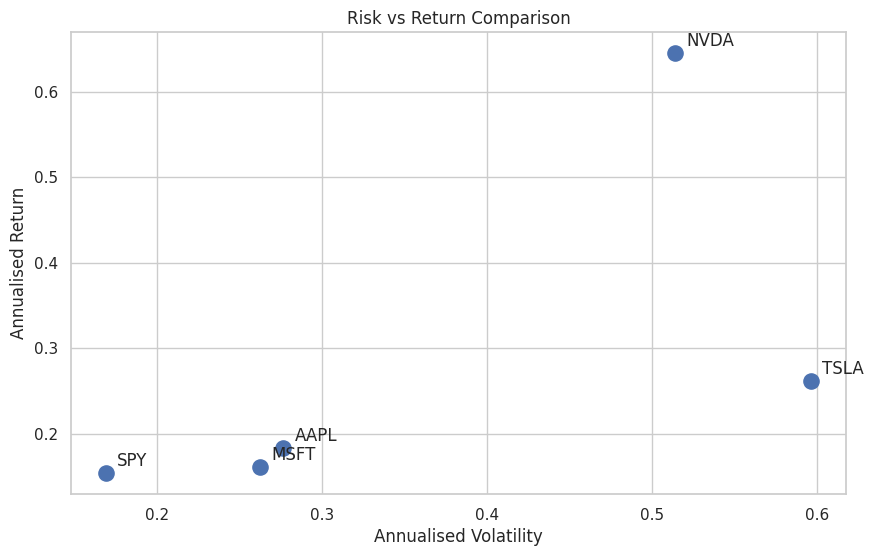

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(
    risk_return_table["Annualised Volatility"],
    risk_return_table["Annualised Return"],
    s=120
)

for ticker in risk_return_table.index:
    plt.annotate(
        ticker,
        (
            risk_return_table.loc[ticker, "Annualised Volatility"],
            risk_return_table.loc[ticker, "Annualised Return"]
        ),
        textcoords="offset points",
        xytext=(8, 5)
    )

plt.title("Risk vs Return Comparison")
plt.xlabel("Annualised Volatility")
plt.ylabel("Annualised Return")
plt.show()

## 12. Simple equal-weight portfolio

This section builds a simple equal-weight portfolio from the selected assets.

Each asset is assigned the same weight.


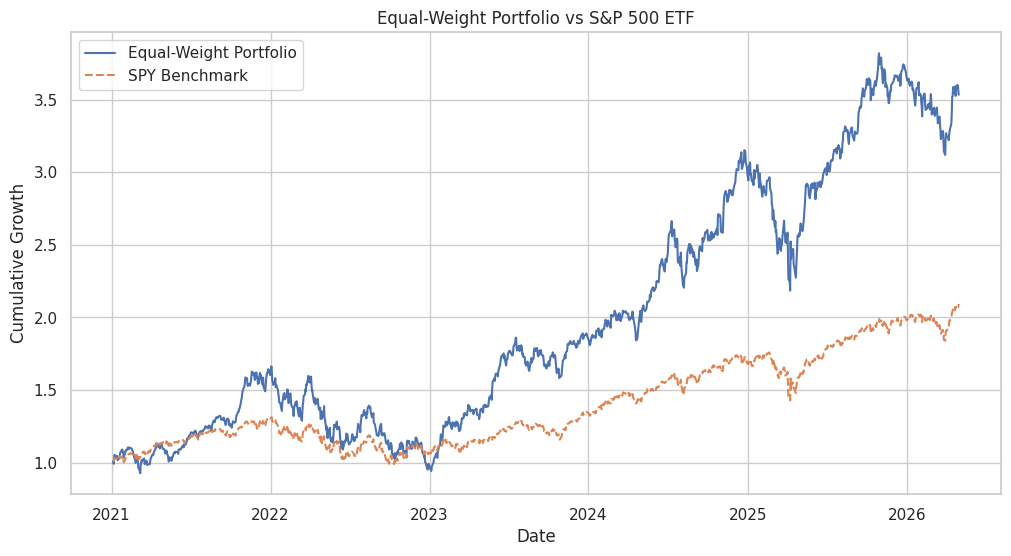

In [16]:
# Equal weights
weights = np.array([1 / len(tickers)] * len(tickers))

# Portfolio daily returns
portfolio_returns = daily_returns.dot(weights)

portfolio_cumulative = (1 + portfolio_returns).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(portfolio_cumulative.index, portfolio_cumulative, label="Equal-Weight Portfolio")
plt.plot(cumulative_returns.index, cumulative_returns["SPY"], label="SPY Benchmark", linestyle="--")

plt.title("Equal-Weight Portfolio vs S&P 500 ETF")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.show()

In [17]:
portfolio_annual_return = portfolio_returns.mean() * 252
portfolio_annual_volatility = portfolio_returns.std() * np.sqrt(252)
portfolio_sharpe = portfolio_annual_return / portfolio_annual_volatility
portfolio_max_drawdown = (portfolio_cumulative / portfolio_cumulative.cummax() - 1).min()

portfolio_summary = pd.DataFrame({
    "Annualised Return": [portfolio_annual_return],
    "Annualised Volatility": [portfolio_annual_volatility],
    "Sharpe Ratio": [portfolio_sharpe],
    "Maximum Drawdown": [portfolio_max_drawdown]
}, index=["Equal-Weight Portfolio"])

portfolio_summary

,Annualised Return,Annualised Volatility,Sharpe Ratio,Maximum Drawdown
Equal-Weight Portfolio,0.2809,0.2927,0.9595,-0.4325


## 13. Key findings

The analysis highlights several important patterns in the behaviour of high-growth technology stocks compared to the broader market, particularly when viewed through both return and risk-based perspectives.

One of the most striking results is the exceptional performance of NVIDIA over the selected time period. Its growth significantly exceeds that of the other assets, which can largely be attributed to the rapid expansion of artificial intelligence and the increasing demand for high-performance computing infrastructure. As AI adoption has accelerated across industries, NVIDIA has become a central player due to its dominance in GPU technology. This has resulted in a level of growth that appears almost structural rather than cyclical, suggesting that market expectations around AI have had a substantial impact on valuation.

However, this strong performance comes with a clear increase in volatility. Both NVIDIA and Tesla exhibit much larger fluctuations in daily returns compared to Apple, Microsoft, and the S&P 500. This reinforces the fundamental relationship between risk and return: assets that deliver the highest gains are also subject to greater uncertainty and sharper price movements. While this may be attractive for growth-focused strategies, it introduces additional risk that may not be suitable for more conservative portfolios.

The correlation analysis further reveals that large technology stocks tend to move closely together, particularly during periods of broader market stress or macroeconomic change. This suggests that despite appearing diversified, a portfolio concentrated in major tech companies may still be highly exposed to common external factors such as interest rate changes, inflation expectations, or shifts in investor sentiment toward growth stocks.

Looking beyond returns, the drawdown analysis provides important insight into downside risk. Even the strongest-performing assets experienced significant declines during certain periods, demonstrating that high cumulative returns can mask underlying volatility. This emphasises the importance of evaluating investments not just based on growth, but also on how they behave during market downturns.

When adjusting for risk using metrics such as the Sharpe ratio, the results become more balanced. While NVIDIA and Tesla deliver the highest raw returns, more stable assets such as Microsoft or SPY often provide more consistent performance relative to the level of risk taken. This highlights the value of risk-adjusted evaluation when comparing assets with very different volatility profiles.

Finally, the equal-weight portfolio demonstrates how diversification can improve overall stability. By combining multiple assets, the portfolio reduces extreme fluctuations and drawdowns, even if it slightly limits the maximum possible return. This reinforces a key principle of portfolio construction: spreading exposure across different assets can help manage risk without completely sacrificing performance.

Overall, the results reflect both the growing influence of technological innovation, particularly artificial intelligence, on financial markets, and the continued importance of core data science and investment principles such as risk management, diversification, and robust performance evaluation.

## 14. Portfolio relevance

This project demonstrates a complete data science workflow using real financial data:

- data collection through Python
- data cleaning and validation
- return engineering
- exploratory data analysis
- risk modelling
- portfolio comparison
- visual storytelling
.


## 15. Possible extensions

This project can and will be extended by:

- adding more stocks or ETFs
- including cryptocurrency data
- testing moving-average trading strategies
- applying Monte Carlo portfolio simulation
- performing portfolio optimisation using Sharpe ratio maximisation
- comparing results across different time periods
- adding macroeconomic features such as interest rates or inflation
